# Hands-on Exercise CLASS Module - Mansurbek Satarov

## Setting up necessary packages

In [2]:
!pip install --user mlxtend

In [3]:
import numpy as np

#Plotting packages
import matplotlib.pyplot as plt
import seaborn as sns

#Classification Algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#Ensemble Methods
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import AdaBoostClassifier

#Mlxtend for visualizing classification decision boundaries
from mlxtend.plotting import plot_decision_regions


## Generating and visualizing data

In [4]:
# Generating Data1

np.random.seed(100)

a = np.random.multivariate_normal([2,2],[[0.5,0], [0,0.5]], 200)
b = np.random.multivariate_normal([4,4],[[0.5,0], [0,0.5]], 200)

Data1_X = np.vstack((a,b))
Data1_Y = np.hstack((np.ones(200).T,np.zeros(200).T)).astype(int)


# Generating Data2

np.random.seed(100)

a1 = np.random.multivariate_normal([2,2],[[0.25,0], [0,0.25]],200)
a2 = np.random.multivariate_normal([2,4],[[0.25,0], [0,0.25]],200)
a3 = np.random.multivariate_normal([4,2],[[0.25,0], [0,0.25]],200)
a4 = np.random.multivariate_normal([4,4],[[0.25,0], [0,0.25]],200)

Data2_X = np.vstack((a1,a4,a2,a3))
Data2_Y = np.hstack((np.ones(400).T,np.zeros(400).T)).astype(int)


# Generating Data3

np.random.seed(100)

a1 = np.random.uniform(4,6,[200,2])
a2 = np.random.uniform(0,10,[200,2])

Data3_X = np.vstack((a1,a2))
Data3_Y = np.hstack((np.ones(200).T,np.zeros(200).T)).astype(int)


# Generating Data4

np.random.seed(100)

Data4_X = np.random.uniform(0,12,[500,2])
Data4_Y = np.ones([500]).astype(int)
Data4_Y[np.multiply(Data4_X[:,0],Data4_X[:,0]) + np.multiply(Data4_X[:,1],Data4_X[:,1]) - 100 < 0 ] = 0

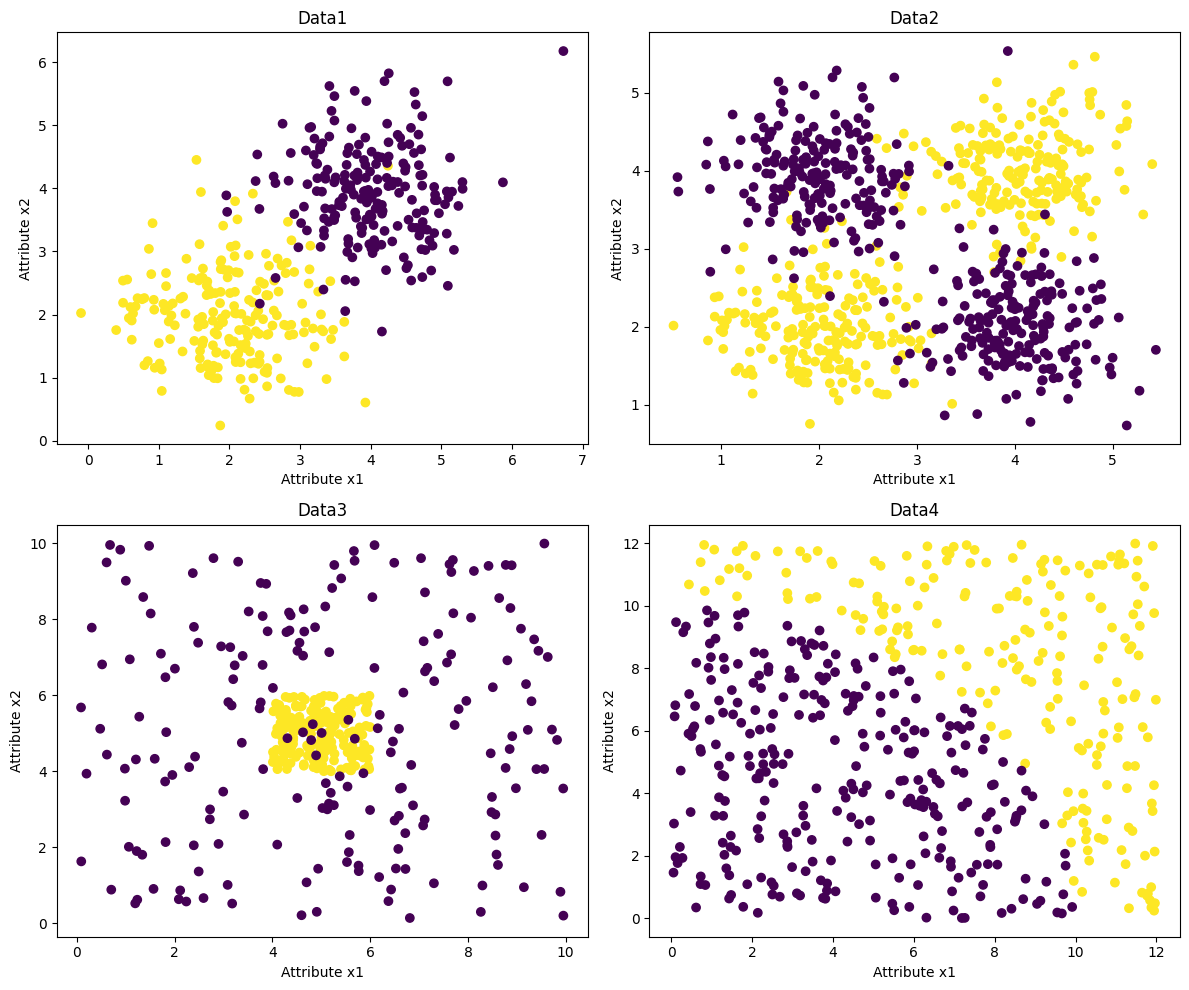

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Data1
axes[0, 0].scatter(Data1_X[:, 0], Data1_X[:, 1], c=Data1_Y)
axes[0, 0].set_title('Data1')
axes[0, 0].set_xlabel('Attribute x1')
axes[0, 0].set_ylabel('Attribute x2')

# Data2
axes[0, 1].scatter(Data2_X[:, 0], Data2_X[:, 1], c=Data2_Y)
axes[0, 1].set_title('Data2')
axes[0, 1].set_xlabel('Attribute x1')
axes[0, 1].set_ylabel('Attribute x2')

# Data3
axes[1, 0].scatter(Data3_X[:, 0], Data3_X[:, 1], c=Data3_Y)
axes[1, 0].set_title('Data3')
axes[1, 0].set_xlabel('Attribute x1')
axes[1, 0].set_ylabel('Attribute x2')

# Data4
axes[1, 1].scatter(Data4_X[:, 0], Data4_X[:, 1], c=Data4_Y)
axes[1, 1].set_title('Data4')
axes[1, 1].set_xlabel('Attribute x1')
axes[1, 1].set_ylabel('Attribute x2')

plt.tight_layout()
plt.show()

## Classification Algorithms

### 1. Decision Tree

Use __Data3__ to answer the following questions.

<span style="color:red">**Question 1a:** </span> Compute and print the 10-fold cross-validation accuracy using decision tree classifiers with max_depth = 2,4,6,8,10, and 50.

In [6]:
depths = [2, 4, 6, 8, 10, 50]

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=100)
    dt_scores = cross_val_score(dt, Data3_X, Data3_Y, cv=10, scoring='accuracy')

    print(f"max_depth = {d}")
    print("10-fold accuracies:", dt_scores)
    print("Mean accuracy:", dt_scores.mean())
    print("Standard deviation:", dt_scores.std())
    print("-" * 50)

max_depth = 2
10-fold accuracies: [0.8   0.9   0.85  0.875 0.925 0.875 0.9   0.85  0.85  0.875]
Mean accuracy: 0.8699999999999999
Standard deviation: 0.033166247903554005
--------------------------------------------------
max_depth = 4
10-fold accuracies: [0.95  0.975 0.975 0.975 1.    1.    0.975 0.925 0.975 0.95 ]
Mean accuracy: 0.97
Standard deviation: 0.021794494717703363
--------------------------------------------------
max_depth = 6
10-fold accuracies: [0.95  0.975 0.975 0.975 1.    1.    0.95  0.925 0.975 0.95 ]
Mean accuracy: 0.9674999999999999
Standard deviation: 0.0225
--------------------------------------------------
max_depth = 8
10-fold accuracies: [0.95  0.975 0.95  0.95  1.    0.975 0.9   0.925 0.975 0.95 ]
Mean accuracy: 0.9549999999999998
Standard deviation: 0.02692582403567251
--------------------------------------------------
max_depth = 10
10-fold accuracies: [0.925 0.975 0.95  0.95  1.    0.975 0.9   0.925 0.95  0.925]
Mean accuracy: 0.9475
Standard deviation: 0.

<span style="color:red">**Question 1b:** </span> For what values of max_depth did you observe the lowest accuracy? What is this phenomenon called?

<span style="color:green">**Answer:** </span>  The lowest accuracy was observed when max_depth = 2, where the mean cross-validation accuracy is 0.87.
This phenomenon is called underfitting.

<span style="color:red">**Question 1c:** </span> What accuracy did you observe for max depth=50? What is the difference between this accuracy and the highest accuracy? What is this phenomenon called?

<span style="color:green">**Answer:** </span> For max_depth = 50, the mean accuracy is 0.9425 (94.25%).
The highest accuracy is 0.97 (97%) at max_depth = 4.

The difference is 0.97−0.9425=0.0275 (2.75%), meaning the accuracy decreased.

This phenomenon is called overfitting.

<span style="color:red">**Question 1d:** </span> Plot decision regions for the above decision tree models

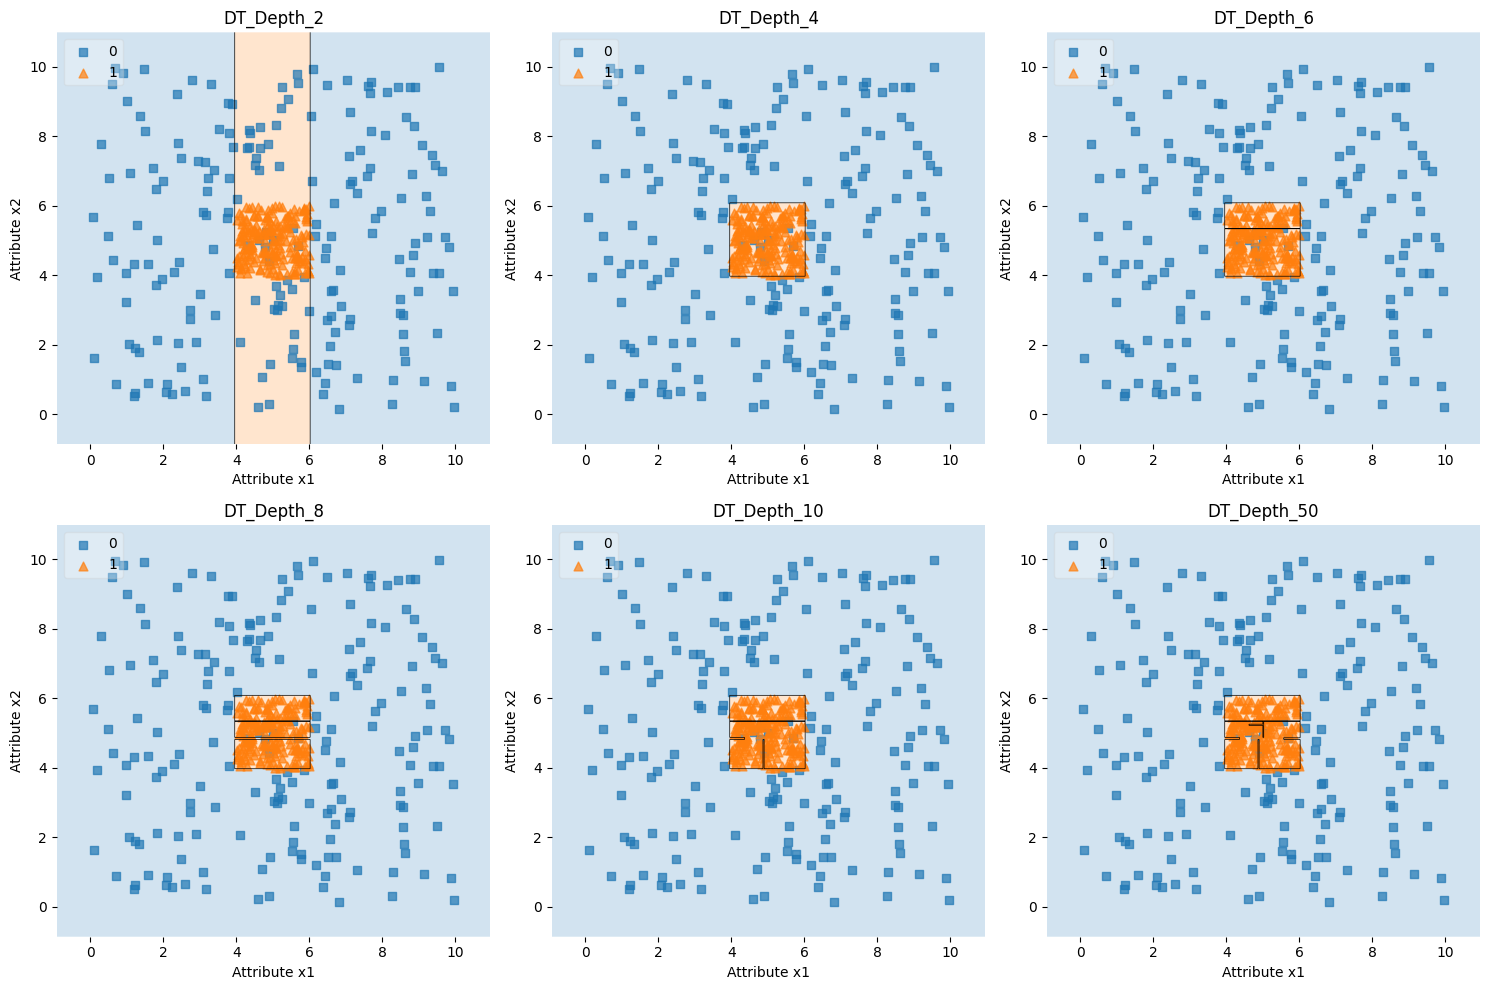

In [7]:
# Parameters for plotting
scatter_kwargs = {'s': 40, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 40, 'label': 'Test data', 'alpha': 0.7}

# Creating one instance for each decision tree depth
dt_2 = DecisionTreeClassifier(max_depth=2, random_state=100)
dt_4 = DecisionTreeClassifier(max_depth=4, random_state=100)
dt_6 = DecisionTreeClassifier(max_depth=6, random_state=100)
dt_8 = DecisionTreeClassifier(max_depth=8, random_state=100)
dt_10 = DecisionTreeClassifier(max_depth=10, random_state=100)
dt_50 = DecisionTreeClassifier(max_depth=50, random_state=100)

# Creating a list of classifiers and their names for plotting
clf_list = [dt_2, dt_4, dt_6, dt_8, dt_10, dt_50]
labels = ['DT_Depth_2', 'DT_Depth_4', 'DT_Depth_6', 'DT_Depth_8', 'DT_Depth_10', 'DT_Depth_50']

# Plotting the decision boundaries
fig = plt.figure(figsize=(15, 10))
count = 0

for clf, label in zip(clf_list, labels):
    count += 1
    clf.fit(Data3_X, Data3_Y)
    ax = plt.subplot(2, 3, count)
    plot_decision_regions(
        X=Data3_X,
        y=Data3_Y,
        clf=clf,
        legend=2,
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(label)

plt.tight_layout()
plt.show()

<span style="color:red">**Question 1e:** </span> Based on the decision regions, which depth is better suited for this data? Explain your reason.

<span style="color:green">**Answer:** </span> The best depth is max_depth = 4. It correctly captures the central cluster while keeping the decision boundary simple. Smaller depth (2) underfits, while larger depths (6, 8, 10, 50) create unnecessarily complex boundaries, indicating possible overfitting.

### 2. k Nearest Neighbor

Use __Data2__ to answer the following questions.

<span style="color:red">**Question 2a:** </span>
 Compute and print the 10-fold cross-validation accuracy for a kNN classifier with n_neighbors = 1, 5, 10, 50

In [8]:
n_neighbors = [1, 5, 10, 50]

for n in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn_scores = cross_val_score(knn, Data2_X, Data2_Y, cv=10, scoring='accuracy')

    print(f"n_neighbors = {n}")
    print("10-fold accuracies:", knn_scores)
    print("Mean accuracy:", knn_scores.mean())
    print("Standard deviation:", knn_scores.std())
    print("-" * 50)

n_neighbors = 1
10-fold accuracies: [0.925  0.8875 0.925  0.8875 0.925  0.9375 0.8875 0.925  0.9375 0.8875]
Mean accuracy: 0.9125
Standard deviation: 0.02091650066335192
--------------------------------------------------
n_neighbors = 5
10-fold accuracies: [0.9875 0.9125 0.925  0.9125 0.95   0.95   0.8625 0.95   0.9625 0.9375]
Mean accuracy: 0.9349999999999999
Standard deviation: 0.0325
--------------------------------------------------
n_neighbors = 10
10-fold accuracies: [0.9875 0.9    0.95   0.925  0.9625 0.95   0.8625 0.9375 0.9625 0.9625]
Mean accuracy: 0.9400000000000001
Standard deviation: 0.03436931771216879
--------------------------------------------------
n_neighbors = 50
10-fold accuracies: [0.9875 0.9    0.9625 0.9125 0.9625 0.9375 0.8875 0.9375 0.9625 0.9625]
Mean accuracy: 0.9412499999999999
Standard deviation: 0.030644126680328173
--------------------------------------------------


<span style="color:red">**Question 2b:** </span> For what values of n_neighbors did you observe the lowest accuracy? What is this phenomenon called?

<span style="color:green">**Answer:** </span> The lowest accuracy occurs at n_neighbors = 1 (0.9125). This is called overfitting, because the model is too sensitive to noise and individual training samples.

<span style="color:red">**Question 2c:** </span>  Plot decision regions for a kNN classifier with n_neighbors = 1, 5, 10, 50

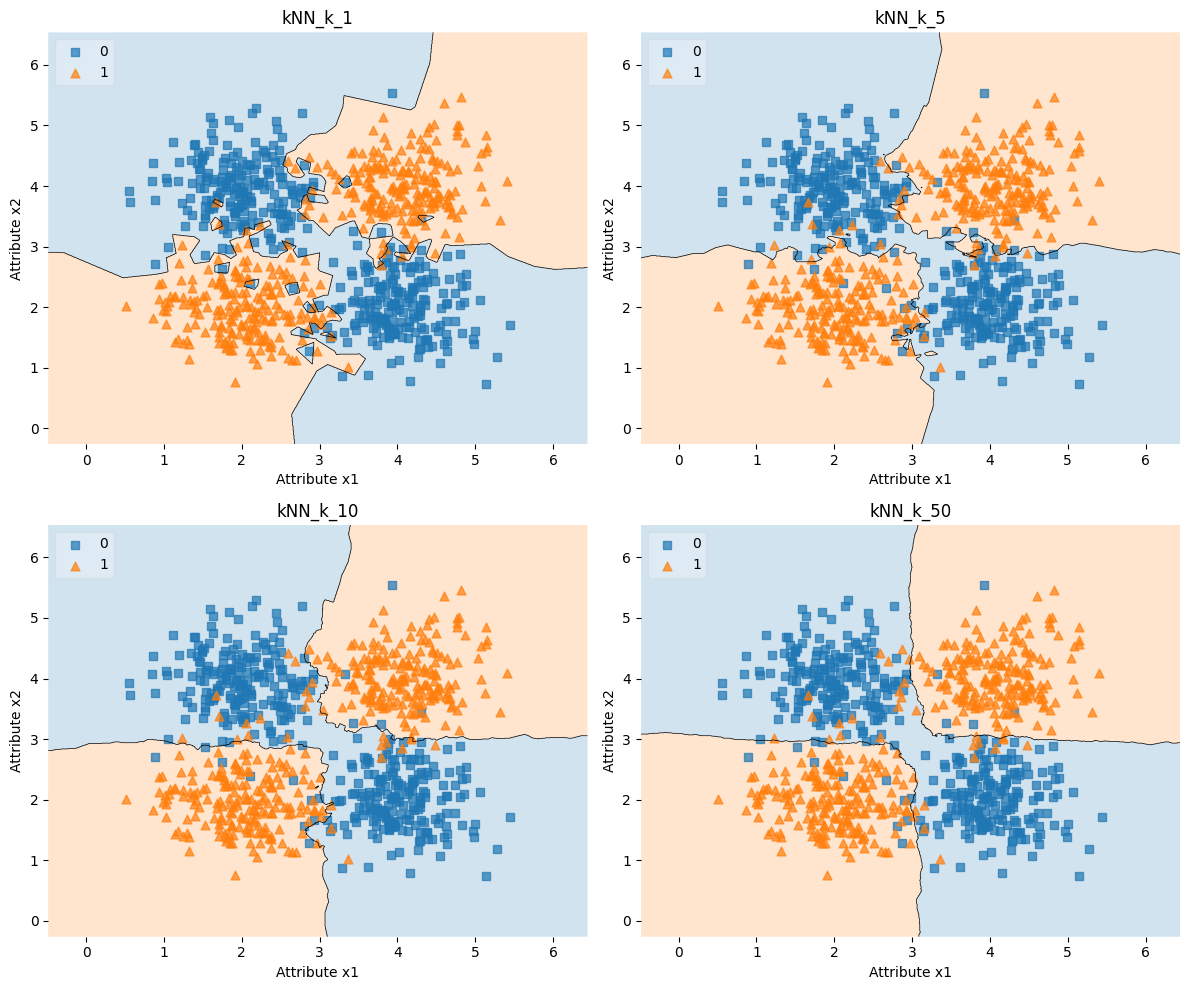

In [9]:
# Parameters for plotting
scatter_kwargs = {'s': 40, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 40, 'label': 'Test data', 'alpha': 0.7}

# Create kNN classifiers
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_10 = KNeighborsClassifier(n_neighbors=10)
knn_50 = KNeighborsClassifier(n_neighbors=50)

# List of classifiers and labels
clf_list = [knn_1, knn_5, knn_10, knn_50]
labels = ['kNN_k_1', 'kNN_k_5', 'kNN_k_10', 'kNN_k_50']

# Plot decision regions
fig = plt.figure(figsize=(12, 10))
count = 0

for clf, label in zip(clf_list, labels):
    count += 1
    clf.fit(Data2_X, Data2_Y)
    ax = plt.subplot(2, 2, count)
    plot_decision_regions(
        X=Data2_X,
        y=Data2_Y,
        clf=clf,
        legend=2,
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(label)

plt.tight_layout()
plt.show()

<span style="color:red">**Question 2d:** </span>  From the plots for __Question 2c__ what do you notice about the nature of decision boundary as the n_neighbors are increasing.

<span style="color:green">**Answer:** </span> As n_neighbors increases, the decision boundary becomes smoother and less complex.
For small k (like k = 1) the boundary is very irregular and sensitive to noise, while larger k values produce smoother boundaries that generalize better for test data.

### 3. Naive Bayes

<span style="color:red">**Question 3a:** </span> Compute and print the 10-fold cross-validation accuracy for a NB classifier on all four datasets: Data1, Data2, Data3, Data4

In [9]:
nb_datasets_X = [Data1_X, Data2_X, Data3_X, Data4_X]
nb_datasets_Y = [Data1_Y, Data2_Y, Data3_Y, Data4_Y]

for index, (dataset_X, dataset_Y) in enumerate(zip(nb_datasets_X, nb_datasets_Y), start=1):
    nb = GaussianNB()
    nb_scores = cross_val_score(nb, dataset_X, dataset_Y, cv=10, scoring='accuracy')

    print(f"Dataset = Data{index}")
    print("10-fold accuracies:", nb_scores)
    print("Mean accuracy:", nb_scores.mean())
    print("Standard deviation:", nb_scores.std())
    print("-" * 50)

Dataset = Data1
10-fold accuracies: [0.975 1.    1.    0.925 0.95  0.975 0.975 0.9   0.975 1.   ]
Mean accuracy: 0.9675
Standard deviation: 0.03172144385112379
--------------------------------------------------
Dataset = Data2
10-fold accuracies: [0.075  0.0625 0.0125 0.0875 0.0875 0.025  0.05   0.05   0.0125 0.0375]
Mean accuracy: 0.049999999999999996
Standard deviation: 0.026809513236909017
--------------------------------------------------
Dataset = Data3
10-fold accuracies: [1.    0.95  0.975 0.975 0.975 0.975 0.925 0.9   0.975 0.95 ]
Mean accuracy: 0.96
Standard deviation: 0.027838821814150098
--------------------------------------------------
Dataset = Data4
10-fold accuracies: [0.92 1.   0.98 0.98 0.96 0.96 0.94 0.96 0.98 0.96]
Mean accuracy: 0.9640000000000001
Standard deviation: 0.02154065922853801
--------------------------------------------------


<span style="color:red">**Question 3b:** </span> State your observations on the datasets the NB algorithm performed poorly.

<span style="color:green">**Answer:** </span>  Naive Bayes performed poorly on Data2, where the accuracy is very low (~0.05). This happens because Naive Bayes assumes that the features are independent and follow a Gaussian distribution, but the structure of Data2 violates these assumptions. The classes in Data2 are arranged in multiple clusters, which Naive Bayes cannot model well with its simple probabilistic assumptions.

<span style="color:red">**Question 3c:** </span> Plot decision regions for a NB classifier on each of the four datasets

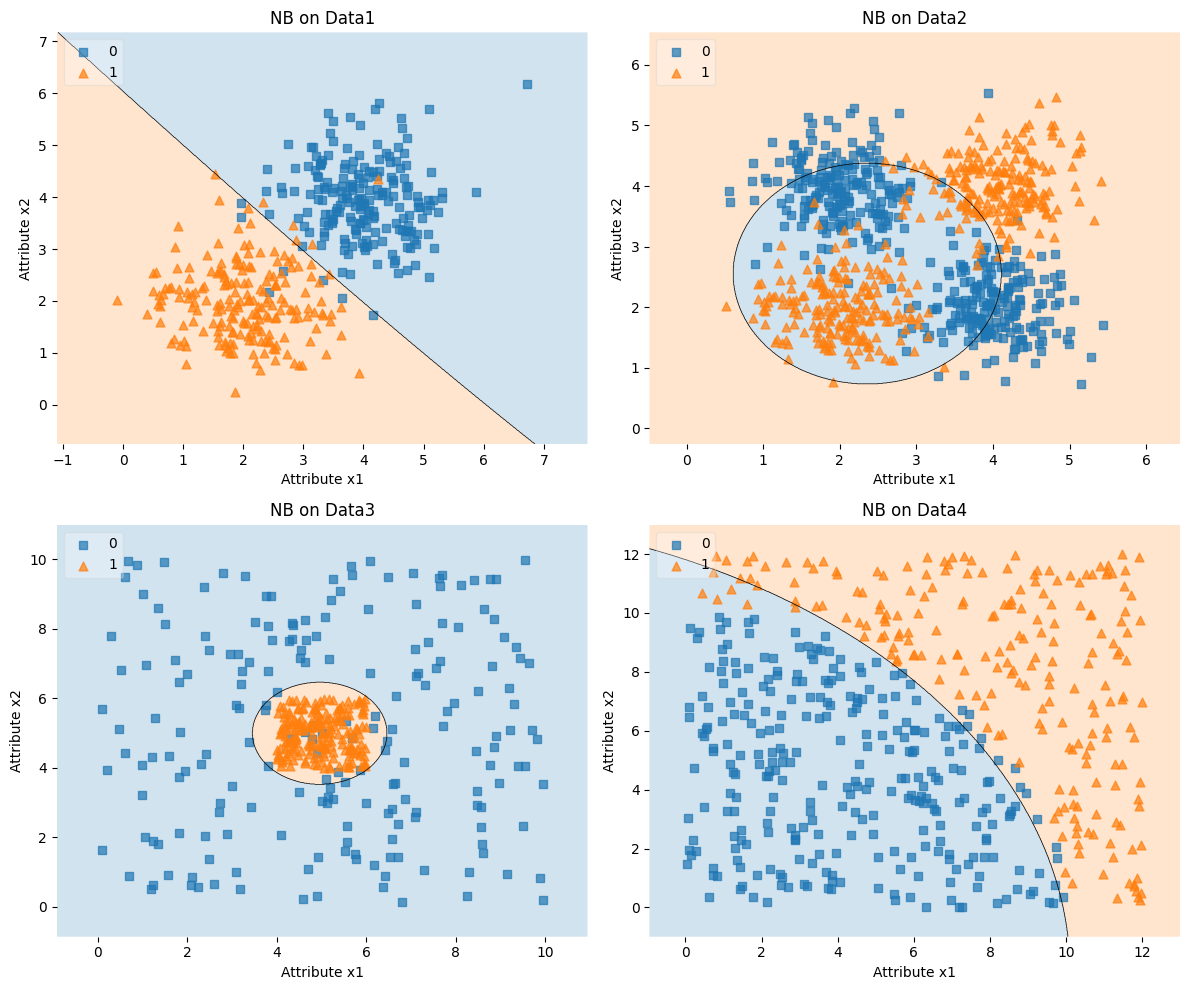

In [10]:
# Parameters for plotting
scatter_kwargs = {'s': 40, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 40, 'label': 'Test data', 'alpha': 0.7}

# Create datasets list
datasets_X = [Data1_X, Data2_X, Data3_X, Data4_X]
datasets_Y = [Data1_Y, Data2_Y, Data3_Y, Data4_Y]
labels = ['NB on Data1', 'NB on Data2', 'NB on Data3', 'NB on Data4']

# Plot decision regions
fig = plt.figure(figsize=(12, 10))
count = 0

for X, y, label in zip(datasets_X, datasets_Y, labels):
    count += 1
    nb = GaussianNB()
    nb.fit(X, y)

    ax = plt.subplot(2, 2, count)
    plot_decision_regions(
        X=X,
        y=y,
        clf=nb,
        legend=2,
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(label)

plt.tight_layout()
plt.show()

<span style="color:red">**Question 3d:** </span> Describe the shape of the decision boundary on all four datasets. Explain the reason.

<span style="color:green">**Answer:** </span> The decision boundaries are mostly linear or elliptical.

* Data1: linear boundary
* Data2: elliptical boundary
* Data3: elliptical boundary
* Data4: curved boundary

This happens because Gaussian Naive Bayes models each class with a Gaussian (normal) distribution, which produces linear or quadratic (elliptical) decision boundaries.

<span style="color:red">**Question 3e:** </span> Based on your plots in __Question 3c__ explain the poor performance of NB on some datasets.

<span style="color:green">**Answer:** </span> Naive Bayes performs poorly on Data2 because the classes form multiple clusters, while NB assumes each class follows a single Gaussian distribution. This incorrect assumption leads to inaccurate decision boundaries and low accuracy.

### 4. Support Vector Machines (Linear)

<span style="color:red">**Question 4a:** </span>  Based on the visualization of the four datasets, assess how well a linear SVM is expected to perform. Specifically, rank the datasets in the order of decreasing accuracy when a linear SVM is used. No need to compute accuracy to answer this question.

<span style="color:green">**Answer:** </span> Data1 → Data4 → Data2 → Data3

Data1 is almost linearly separable, Data4 is somewhat separable, Data2 has multiple clusters, and Data3 is not linearly separable.


<span style="color:red">**Question 4b:** </span>  Compute and print the 10-fold cross-validation accuracy for a linear SVM classifier on all four datasets: Data1, Data2, Data3, Data4

In [11]:
svm_datasets_X = [Data1_X, Data2_X, Data3_X, Data4_X]
svm_datasets_Y = [Data1_Y, Data2_Y, Data3_Y, Data4_Y]

for index, (dataset_X, dataset_Y) in enumerate(zip(svm_datasets_X, svm_datasets_Y), start=1):
    svm_linear = SVC(C=0.5, kernel='linear')
    svm_linear_scores = cross_val_score(svm_linear, dataset_X, dataset_Y, cv=10, scoring='accuracy')

    print(f"Dataset = Data{index}")
    print("10-fold accuracies:", svm_linear_scores)
    print("Mean accuracy:", svm_linear_scores.mean())
    print("Standard deviation:", svm_linear_scores.std())
    print("-" * 50)

Dataset = Data1
10-fold accuracies: [0.975 1.    1.    0.95  0.95  0.95  0.975 0.9   0.975 1.   ]
Mean accuracy: 0.9674999999999999
Standard deviation: 0.02968585521759479
--------------------------------------------------
Dataset = Data2
10-fold accuracies: [0.125  0.1375 0.0125 0.0875 0.2    0.2375 0.1    0.15   0.1875 0.175 ]
Mean accuracy: 0.14125000000000001
Standard deviation: 0.06124999999999999
--------------------------------------------------
Dataset = Data3
10-fold accuracies: [0.625 0.625 0.65  0.6   0.65  0.7   0.65  0.675 0.625 0.625]
Mean accuracy: 0.6425000000000001
Standard deviation: 0.0275
--------------------------------------------------
Dataset = Data4
10-fold accuracies: [0.94 0.92 0.9  0.94 0.94 0.9  0.94 0.92 0.96 0.86]
Mean accuracy: 0.9219999999999999
Standard deviation: 0.02749545416973502
--------------------------------------------------


<span style="color:red">**Question 4c:** </span> Rank the datasets in the decreasing order of accuracy of SVM.

<span style="color:green">**Answer:** </span> Data1 → Data4 → Data3 → Data2

Based on the mean accuracies:

- Data1: 0.9675
- Data4: 0.9220
- Data3: 0.6425
- Data2: 0.1413


<span style="color:red">**Question 4d:** </span>  Plot decision regions for a linear SVM classifier on each of the four datasets

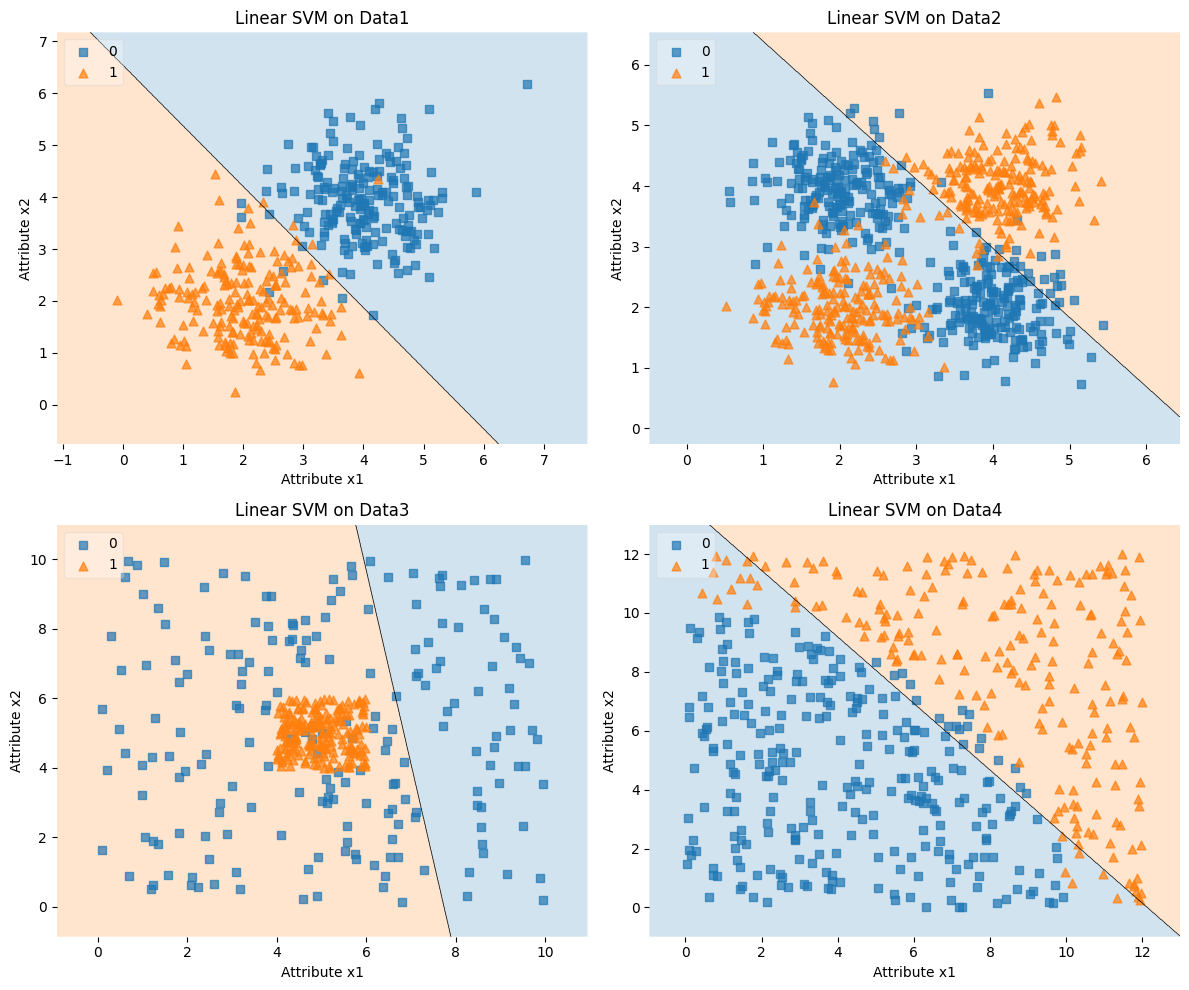

In [12]:
# Parameters for plotting
scatter_kwargs = {'s': 40, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 40, 'label': 'Test data', 'alpha': 0.7}

# Create datasets list
datasets_X = [Data1_X, Data2_X, Data3_X, Data4_X]
datasets_Y = [Data1_Y, Data2_Y, Data3_Y, Data4_Y]
labels = ['Linear SVM on Data1', 'Linear SVM on Data2', 'Linear SVM on Data3', 'Linear SVM on Data4']

# Plot decision regions
fig = plt.figure(figsize=(12, 10))
count = 0

for X, y, label in zip(datasets_X, datasets_Y, labels):
    count += 1
    svm_linear = SVC(C=0.5, kernel='linear')
    svm_linear.fit(X, y)

    ax = plt.subplot(2, 2, count)
    plot_decision_regions(
        X=X,
        y=y,
        clf=svm_linear,
        legend=2,
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(label)

plt.tight_layout()
plt.show()

<span style="color:red">**Question 4e:** </span>Explain the reason for your observations in __Question 4c__ using observations from the above decision regions.

<span style="color:green">**Answer:** </span> Linear SVM performs best on Data1 because the classes are almost linearly separable. It performs well on Data4 since the linear boundary approximates the separation reasonably. Performance decreases on Data3 because the classes require a non-linear boundary, and it performs worst on Data2 due to multiple clusters that cannot be separated with one straight line.


### 5. Non-linear Support Vector Machines

Use __Data2__ to answer the following questions.

<span style="color:red">**Question 5a:** </span>
Compute and print the 10-fold cross-validation accuracy for an SVM with a polynomial kernel and degree values 1, 2, and 3.

In [13]:
svm_poly_degrees = [1, 2, 3]

for poly_degree in svm_poly_degrees:
    svm_poly = SVC(C=0.5, kernel='poly', degree=poly_degree, gamma='auto')
    svm_poly_scores = cross_val_score(svm_poly, Data2_X, Data2_Y, cv=10, scoring='accuracy')

    print(f"Degree = {poly_degree}")
    print("10-fold accuracies:", svm_poly_scores)
    print("Mean accuracy:", svm_poly_scores.mean())
    print("Standard deviation:", svm_poly_scores.std())
    print("-" * 50)

Degree = 1
10-fold accuracies: [0.1375 0.125  0.0125 0.0875 0.175  0.1875 0.1    0.1625 0.1875 0.1625]
Mean accuracy: 0.13375
Standard deviation: 0.05215661511256266
--------------------------------------------------
Degree = 2
10-fold accuracies: [0.8125 0.8375 0.8875 0.8375 0.8875 0.8875 0.8625 0.8875 0.9125 0.8375]
Mean accuracy: 0.865
Standard deviation: 0.030516389039334235
--------------------------------------------------
Degree = 3
10-fold accuracies: [0.825  0.875  0.8875 0.8625 0.925  0.9    0.8625 0.8875 0.8875 0.85  ]
Mean accuracy: 0.8762500000000001
Standard deviation: 0.026487025125521375
--------------------------------------------------


<span style="color:red">**Question 5b:** </span> Rank the polynomial kernels in decreasing order of accuracy.

<span style="color:green">**Answer:** </span> Degree 3 → Degree 2 → Degree 1

Because the mean accuracies are:

* Degree 3: **0.8763**
* Degree 2: **0.8650**
* Degree 1: **0.1338**



<span style="color:red">**Question 5c:** </span>  Plot decision regions for a polynomial kernel SVM with degree values 1, 2, and 3.

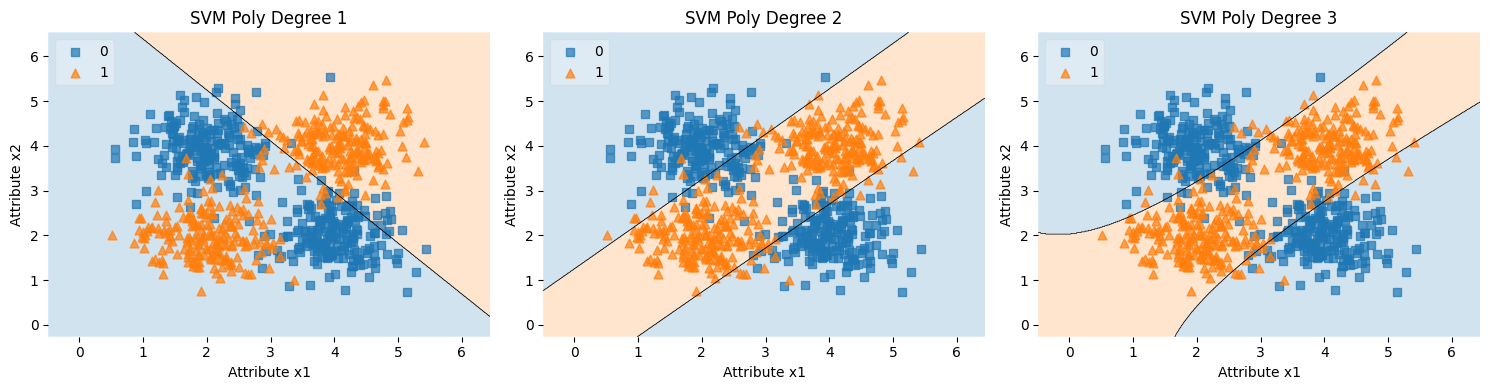

In [14]:
# Parameters for plotting
scatter_kwargs = {'s': 40, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 40, 'label': 'Test data', 'alpha': 0.7}

# Create polynomial SVM classifiers
svm_poly_1 = SVC(C=0.5, kernel='poly', degree=1, gamma='auto')
svm_poly_2 = SVC(C=0.5, kernel='poly', degree=2, gamma='auto')
svm_poly_3 = SVC(C=0.5, kernel='poly', degree=3, gamma='auto')

# List of classifiers and labels
clf_list = [svm_poly_1, svm_poly_2, svm_poly_3]
labels = ['SVM Poly Degree 1', 'SVM Poly Degree 2', 'SVM Poly Degree 3']

# Plot decision regions
fig = plt.figure(figsize=(15, 4))
count = 0

for clf, label in zip(clf_list, labels):
    count += 1
    clf.fit(Data2_X, Data2_Y)
    ax = plt.subplot(1, 3, count)
    plot_decision_regions(
        X=Data2_X,
        y=Data2_Y,
        clf=clf,
        legend=2,
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(label)

plt.tight_layout()
plt.show()

<span style="color:red">**Question 5d:** </span> Based on the decision regions, explain the reason for your observations in __Question 5c__.

<span style="color:green">**Answer:** </span> As the polynomial degree increases, the decision boundary becomes more flexible and curved.
Degree 1 produces a linear boundary that cannot separate the clusters well, while degrees 2 and 3 create curved boundaries that better fit the cluster structure in Data2, leading to higher accuracy.



<span style="color:red">**Question 5e:** </span>  Compute the 10-fold cross-validation accuracy for an SVM with an RBF kernel and gamma values 0.01, 0.1, and 1.

In [15]:
svm_rbf_gammas = [0.01, 0.1, 1]

for rbf_gamma in svm_rbf_gammas:
    svm_rbf = SVC(C = 0.5, kernel='rbf', gamma=rbf_gamma)
    svm_rbf_scores = cross_val_score(svm_rbf, Data2_X, Data2_Y, cv=10, scoring='accuracy')

    print(f"SVM with an RBF kernel and gamma = {rbf_gamma}")
    print("10-fold accuracies:", svm_rbf_scores)
    print("Mean accuracy:", svm_rbf_scores.mean())
    print("Standard deviation:", svm_rbf_scores.std())
    print("-" * 50)

SVM with an RBF kernel and gamma = 0.01
10-fold accuracies: [0.375  0.3125 0.0875 0.25   0.4375 0.3375 0.3    0.3    0.275  0.3375]
Mean accuracy: 0.30124999999999996
Standard deviation: 0.08704345179276841
--------------------------------------------------
SVM with an RBF kernel and gamma = 0.1
10-fold accuracies: [0.975  0.9    0.9375 0.9    0.9625 0.9375 0.8875 0.9375 0.9625 0.9625]
Mean accuracy: 0.93625
Standard deviation: 0.02928843628464996
--------------------------------------------------
SVM with an RBF kernel and gamma = 1
10-fold accuracies: [0.9875 0.9125 0.95   0.925  0.9625 0.9375 0.875  0.9375 0.9625 0.95  ]
Mean accuracy: 0.9399999999999998
Standard deviation: 0.029474565306379
--------------------------------------------------


<span style="color:red">**Question 5f:** </span> Rank the RBF kernels in decreasing order of accuracy.

<span style="color:green">**Answer:** </span> RBF (γ = 1) → RBF (γ = 0.1) → RBF (γ = 0.01)

Based on the mean accuracies:
- γ = 1: 0.94
- γ = 0.1: 0.936
- γ = 0.01: 0.301


<span style="color:red">**Question 5g:** </span>  Plot decision regions for the above RBF Kernels

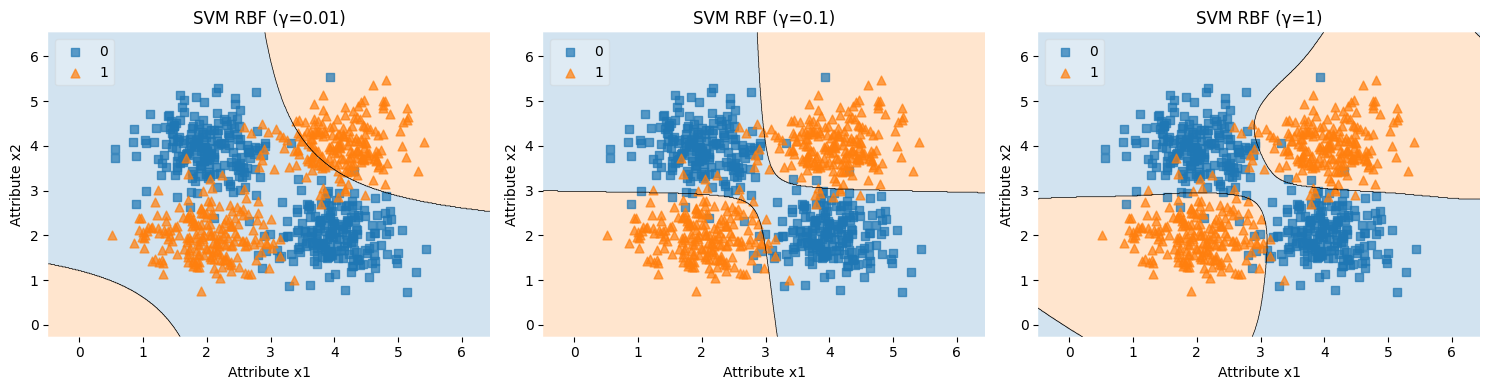

In [16]:
# Parameters for plotting
scatter_kwargs = {'s': 40, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 40, 'label': 'Test data', 'alpha': 0.7}

# Create RBF SVM classifiers
svm_rbf_001 = SVC(C=0.5, kernel='rbf', gamma=0.01)
svm_rbf_01 = SVC(C=0.5, kernel='rbf', gamma=0.1)
svm_rbf_1 = SVC(C=0.5, kernel='rbf', gamma=1)

# List of classifiers and labels
clf_list = [svm_rbf_001, svm_rbf_01, svm_rbf_1]
labels = ['SVM RBF (γ=0.01)', 'SVM RBF (γ=0.1)', 'SVM RBF (γ=1)']

# Plot decision regions
fig = plt.figure(figsize=(15, 4))
count = 0

for clf, label in zip(clf_list, labels):
    count += 1
    clf.fit(Data2_X, Data2_Y)
    ax = plt.subplot(1, 3, count)
    plot_decision_regions(
        X=Data2_X,
        y=Data2_Y,
        clf=clf,
        legend=2,
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(label)

plt.tight_layout()
plt.show()

<span style="color:red">**Question 5h:** </span>  Explain the reason for your observations in __Question 5f__ from the above decision regions.

<span style="color:green">**Answer:** </span> As gamma increases, the decision boundary becomes more flexible and fits the clusters better.
With gamma = 0.01, the boundary is too smooth and underfits the data.
With gamma = 0.1 and gamma = 1, the boundary better captures the cluster structure, leading to higher accuracy.




<span style="color:red">**Question 5i:** </span>  Between SVM with a Polynomial kernel and SVM with an RBF kernel, which one is ideally suited of Data2? Explain your reason.

<span style="color:green">**Answer:** </span> SVM with the RBF kernel is better suited for Data2 because it can create more flexible non-linear decision boundaries that better capture the cluster structure of the dataset, leading to higher accuracy than the polynomial kernel.




### 6. Classification Evaluation

<span style="color:red">**Question 6a:** </span>

Run SVM classifier (with RBF kernel and gamma=0.1) on __Data2__ and compute the mean of k-fold cross-validation accuracies for cv = 3, 4, 5 and 6. Report the mean of accuracies for each choice of 'cv' and explain the reason for any differences in the mean accuracy you observe.

In [17]:
svm_rbf_cvs = [3, 4, 5, 6]

for cv_value in svm_rbf_cvs:
    svm_rbf = SVC(C=0.5, kernel='rbf', gamma=0.1)
    svm_rbf_scores = cross_val_score(svm_rbf, Data2_X, Data2_Y, cv=cv_value, scoring='accuracy')

    print(f"SVM with RBF kernel (gamma=0.1), cv={cv_value}")
    print("Fold accuracies:", svm_rbf_scores)
    print("Mean accuracy:", svm_rbf_scores.mean())
    print("Standard deviation:", svm_rbf_scores.std())
    print("-" * 50)

SVM with RBF kernel (gamma=0.1), cv=3
Fold accuracies: [0.87265918 0.93632959 0.90225564]
Mean accuracy: 0.903748134380896
Standard deviation: 0.026014752189391494
--------------------------------------------------
SVM with RBF kernel (gamma=0.1), cv=4
Fold accuracies: [0.91  0.92  0.895 0.94 ]
Mean accuracy: 0.91625
Standard deviation: 0.0163458710382775
--------------------------------------------------
SVM with RBF kernel (gamma=0.1), cv=5
Fold accuracies: [0.91875 0.9     0.95    0.9125  0.95625]
Mean accuracy: 0.9275
Standard deviation: 0.02186606960566988
--------------------------------------------------
SVM with RBF kernel (gamma=0.1), cv=6
Fold accuracies: [0.95522388 0.89552239 0.94736842 0.90977444 0.93984962 0.94736842]
Mean accuracy: 0.9325178618187259
Standard deviation: 0.021970907802390045
--------------------------------------------------


<span style="color:green">**Answer:** </span> The mean accuracies are:

- cv = 3: 0.9037
- cv = 4: 0.9163
- cv = 5: 0.9275
- cv = 6: 0.9325

As cv increases, the mean accuracy increases slightly. This happens because with more folds, the model is trained on a larger portion of the data in each run, so the estimate of performance becomes a bit better and more reliable. The differences are small because the classifier already performs consistently well on this dataset.

<span style="color:red">**Question 6b:** </span>

For DT, NB, kNN, Linear SVM, Polynomial Kernel SVM, and SVM with RBF kernel classifiers, compute the 30-fold crossvalidation __accuracies__ and __precision__ (use scoring='precision' when calling cross_val_score()) on __Data3__. Rank the classifiers based on accuracy and precision scores. Are the best classifiers ranked according to accuracy and precision the same? If not, explain the reason.

For the classifiers, feel free to choose any parameter settings you prefer.

In [18]:
# Define classifiers (choose reasonable parameters)
classifiers = {
    "DT": DecisionTreeClassifier(max_depth=4, random_state=100),
    "NB": GaussianNB(),
    "kNN": KNeighborsClassifier(n_neighbors=10),
    "Linear SVM": SVC(kernel='linear', C=0.5),
    "Poly SVM": SVC(kernel='poly', degree=3, C=0.5, gamma='auto'),
    "RBF SVM": SVC(kernel='rbf', gamma=0.1, C=0.5)
}

results = []

for name, clf in classifiers.items():

    acc_scores = cross_val_score(clf, Data3_X, Data3_Y, cv=30, scoring='accuracy')
    prec_scores = cross_val_score(clf, Data3_X, Data3_Y, cv=30, scoring='precision')

    acc_mean = acc_scores.mean()
    prec_mean = prec_scores.mean()

    results.append((name, acc_mean, prec_mean))

    print(name)
    print("Accuracy:", acc_mean)
    print("Precision:", prec_mean)
    print("-"*40)

# Ranking
print("\nRanking by Accuracy:")
print(sorted(results, key=lambda x: x[1], reverse=True))

print("\nRanking by Precision:")
print(sorted(results, key=lambda x: x[2], reverse=True))

DT
Accuracy: 0.96978021978022
Precision: 0.9541666666666668
----------------------------------------
NB
Accuracy: 0.9597069597069599
Precision: 0.9294973544973547
----------------------------------------
kNN
Accuracy: 0.9371794871794872
Precision: 0.8950925925925926
----------------------------------------
Linear SVM
Accuracy: 0.6406593406593408
Precision: 0.5875420875420876
----------------------------------------
Poly SVM
Accuracy: 0.8553113553113554
Precision: 0.7944396344396345
----------------------------------------
RBF SVM
Accuracy: 0.93992673992674
Precision: 0.8986640211640212
----------------------------------------

Ranking by Accuracy:
[('DT', np.float64(0.96978021978022), np.float64(0.9541666666666668)), ('NB', np.float64(0.9597069597069599), np.float64(0.9294973544973547)), ('RBF SVM', np.float64(0.93992673992674), np.float64(0.8986640211640212)), ('kNN', np.float64(0.9371794871794872), np.float64(0.8950925925925926)), ('Poly SVM', np.float64(0.8553113553113554), np.float

<span style="color:green">**Answer:** </span> The classifiers ranked by decreasing accuracy are:

DT > NB > RBF SVM > kNN > Poly SVM > Linear SVM

The classifiers ranked by decreasing precision are:

DT > NB > RBF SVM > kNN > Poly SVM > Linear SVM

So, yes, the best classifiers ranked by accuracy and precision are the same in this case.
The best classifier is Decision Tree (DT) for both measures.

This happens because the models that correctly classify more points on Data3 also tend to make more correct positive predictions, so both accuracy and precision produce the same ranking here.



### 7. Ensemble Methods

<span style="color:red">**Question 7a:** </span>
 __Bagging:__ Create bagging classifiers each with n_estimators = 1,2,3,4,5,10, and 20. Use a **linear SVM** (with C=0.5) as a base classifier. Using __Data3__, compute the mean __5-fold__ cross validation accuracies and standard deviation for each of the bagging classifiers. State your observations on how bagging affected the mean and standard deviation of the base classifier. Explain your reason for what may have lead to these observations.

In [19]:
svm_linear = SVC(C=0.5, kernel='linear')
n_est_list = [1,2,3,4,5,10, 20]
for n_est in n_est_list:
    # create an instance of bagging classifier with 'n_est' estimators
    bagging = BaggingClassifier(estimator=svm_linear, n_estimators=n_est, random_state=100)
    # compute cross-validation accuracy for each bagging classifier
    scores = cross_val_score(bagging, Data3_X, Data3_Y, cv=5, scoring='accuracy')
    print("Bagging Accuracy: %.2f (+/- %.2f) #estimators: %d" % (scores.mean(), scores.std(), n_est))

Bagging Accuracy: 0.52 (+/- 0.05) #estimators: 1
Bagging Accuracy: 0.53 (+/- 0.06) #estimators: 2
Bagging Accuracy: 0.67 (+/- 0.05) #estimators: 3
Bagging Accuracy: 0.60 (+/- 0.08) #estimators: 4
Bagging Accuracy: 0.69 (+/- 0.05) #estimators: 5
Bagging Accuracy: 0.68 (+/- 0.03) #estimators: 10
Bagging Accuracy: 0.64 (+/- 0.02) #estimators: 20


<span style="color:green">**Answer:** </span> The mean 5-fold cross-validation accuracies are:

* 1 estimator: 0.52 ± 0.05
* 2 estimators: 0.53 ± 0.06
* 3 estimators: 0.67 ± 0.05
* 4 estimators: 0.60 ± 0.08
* 5 estimators: 0.69 ± 0.05
* 10 estimators: 0.68 ± 0.03
* 20 estimators: 0.64 ± 0.02


Observations:
Bagging improved the mean accuracy compared to using very few estimators, with the best result around 5 estimators. It also generally reduced the standard deviation when the number of estimators became larger, especially at 10 and 20 estimators.

Reason:
Bagging helps by averaging predictions from multiple models, which can reduce variability. However, the improvement is limited because the base classifier is a linear SVM, and Data3 is not linearly separable, so bagging cannot fully solve that mismatch.



<span style="color:red">**Question 7b:** </span>
 Plot decision regions for the above bagging classifiers.

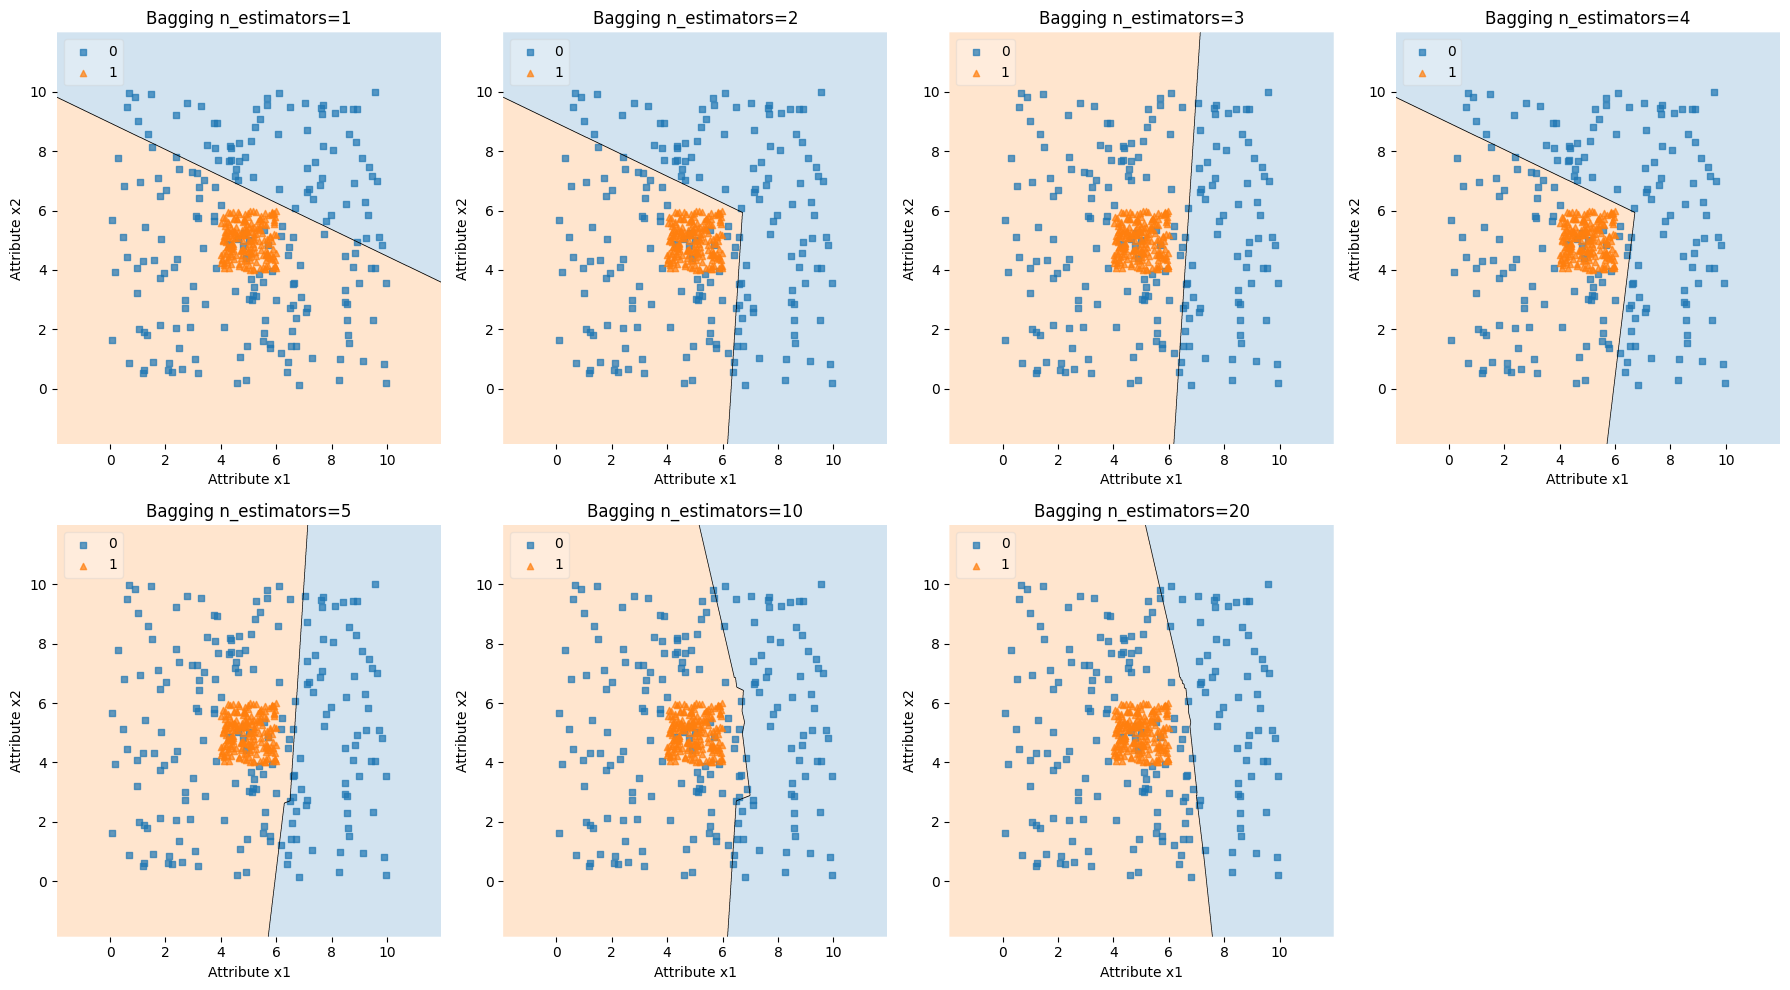

In [21]:
# Parameters for plotting
scatter_kwargs = {'s': 20, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 20, 'label': 'Test data', 'alpha': 0.7}

svm_linear = SVC(C=0.5, kernel='linear')
n_est_list = [1, 2, 3, 4, 5, 10, 20]

fig = plt.figure(figsize=(18, 10))
count = 0

for n_est in n_est_list:
    count += 1
    bagging = BaggingClassifier(estimator=svm_linear, n_estimators=n_est, random_state=100)
    bagging.fit(Data3_X, Data3_Y)

    ax = plt.subplot(2, 4, count)
    plot_decision_regions(
        X=Data3_X,
        y=Data3_Y,
        clf=bagging,
        legend=2,
        zoom_factor=0.5,   # makes the grid less dense, so much faster
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(f'Bagging n_estimators={n_est}')

plt.tight_layout()
plt.show()

<span style="color:red">**Question 7c:** </span>
 Comment on the quality of the decision regions for a bagging classifiers with many estimators when compared to that of only one estimator.

<span style="color:green">**Answer:** </span> When the bagging classifier uses only one estimator, the decision boundary is simpler and more unstable, since it depends on a single model trained on one bootstrap sample.

When many estimators are used (e.g., 10 or 20), the decision regions become more stable and smoother. The ensemble averages the predictions from multiple models, which reduces the effect of noise or variations from individual training samples.

As seen in the plots, increasing the number of estimators produces more consistent decision boundaries, although the overall shape remains roughly linear because the base classifier is a linear SVM. Thus, bagging mainly improves stability and robustness rather than dramatically changing the boundary shape.



<span style="color:red">**Question 7d:** </span>
 **Boosting:**  Create boosting classifiers each with n_estimators = 1,2,3,4,5,10, 20, and 40. Use a **Decision Tree** (with max_depth=2) as a base classifier. Using __Data2__, compute the mean **10-fold** cross validation accuracies and standard deviation for each of the bagging classifiers. State your observations on how boosting affected the mean and standard deviation of the base classifier.

In [23]:
dt = DecisionTreeClassifier(max_depth=2)
n_est_list = [1, 2, 3, 4, 5, 10, 20, 40]
for n_est in n_est_list:
    # create an instance of bagging classifier with 'n_est' estimators
    boosting = AdaBoostClassifier(estimator=dt, n_estimators=n_est, random_state=100)
    # compute cross-validation accuracy for each bagging classifier
    scores = cross_val_score(boosting, Data2_X, Data2_Y, cv=10, scoring='accuracy')
    print("Boosting Accuracy: %.2f (+/- %.2f) #estimators: %d" % (scores.mean(), scores.std(), n_est))

Boosting Accuracy: 0.88 (+/- 0.03) #estimators: 1
Boosting Accuracy: 0.90 (+/- 0.04) #estimators: 2
Boosting Accuracy: 0.92 (+/- 0.03) #estimators: 3
Boosting Accuracy: 0.91 (+/- 0.03) #estimators: 4
Boosting Accuracy: 0.92 (+/- 0.03) #estimators: 5
Boosting Accuracy: 0.92 (+/- 0.03) #estimators: 10
Boosting Accuracy: 0.92 (+/- 0.03) #estimators: 20
Boosting Accuracy: 0.92 (+/- 0.03) #estimators: 40


<span style="color:green">**Answer:** </span> The mean 10-fold accuracies are:
* 1 estimator: 0.88 ± 0.03
* 2 estimators: 0.90 ± 0.04
* 3 estimators: 0.92 ± 0.03
* 4 estimators: 0.91 ± 0.03
* 5 estimators: 0.92 ± 0.03
* 10 estimators: 0.92 ± 0.03
* 20 estimators: 0.92 ± 0.03
* 40 estimators: 0.92 ± 0.03

Observations:
Boosting increases the mean accuracy from 0.88 to about 0.92 as the number of estimators increases. After around 3 estimators, the accuracy mostly levels off. The standard deviation stays small and fairly stable, around 0.03–0.04.

Reason:
Boosting improves performance by combining weak learners sequentially and focusing more on previously misclassified points. This helps the model classify Data2 better. After a certain number of estimators, the gain becomes small because the ensemble has already captured most of the useful structure in the data.


<span style="color:red">**Question 7e:** </span>
 Plot decision regions for above boosting classifiers. Explain your reason for what may have lead to the observations in __Question 7d__.

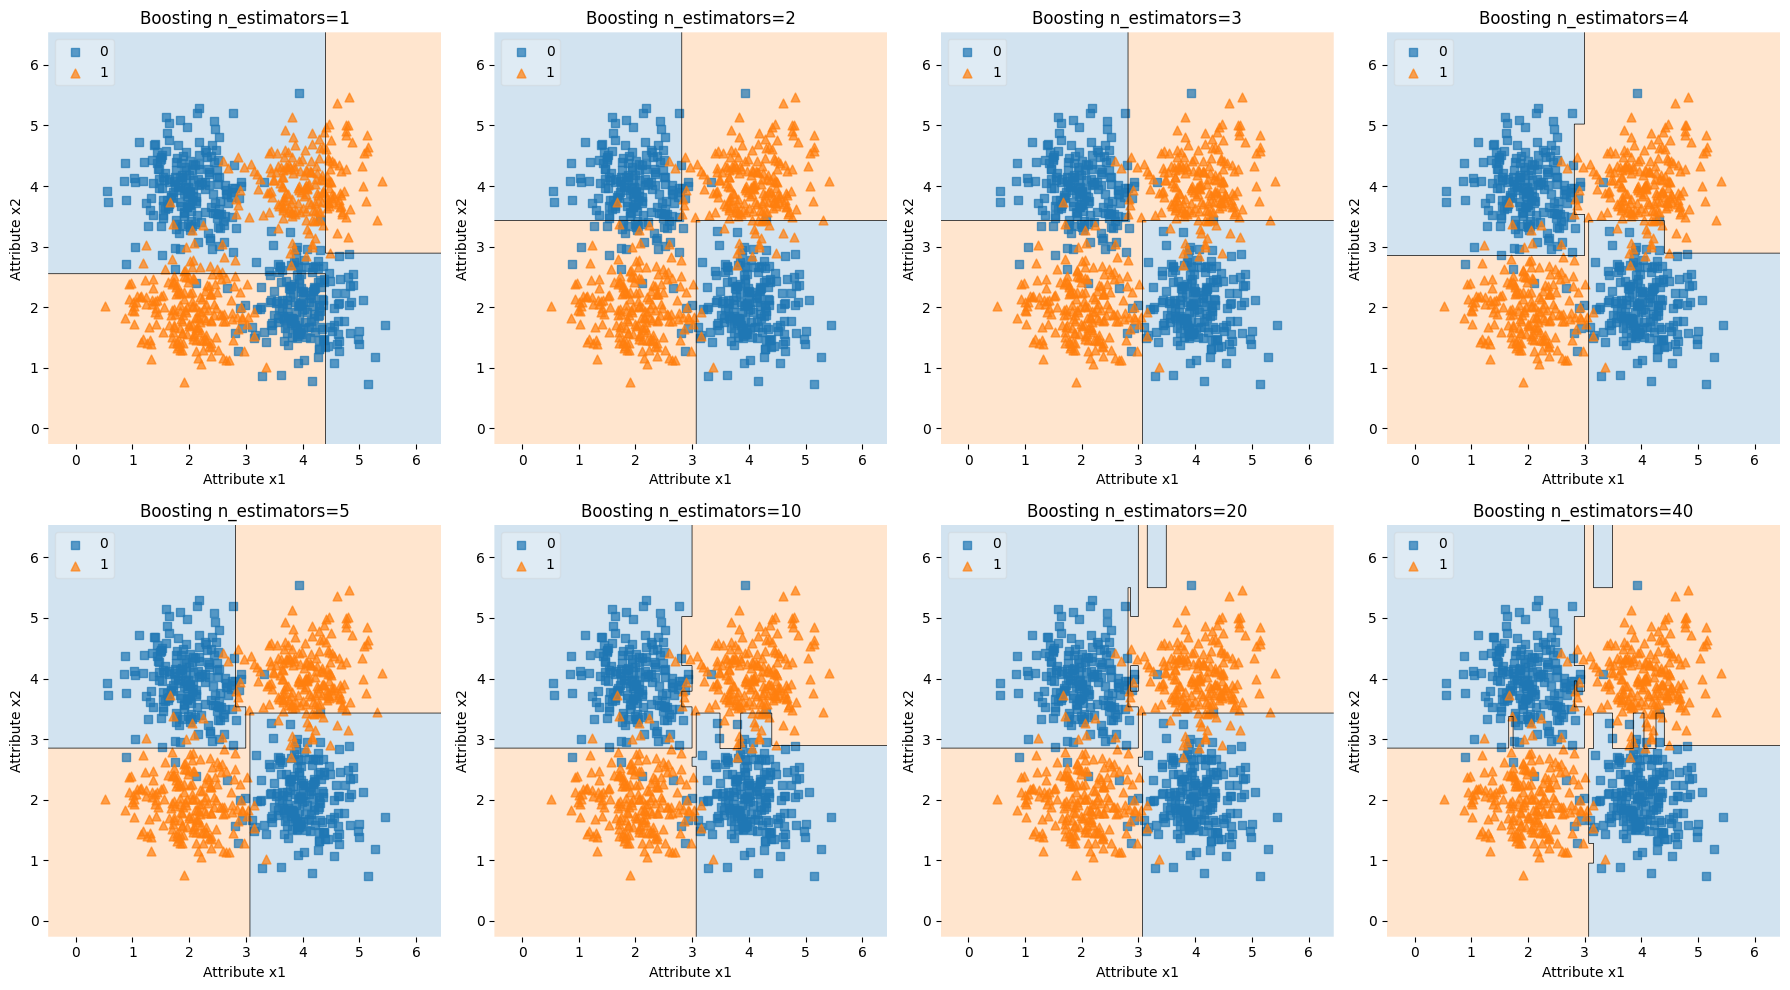

In [24]:
# Parameters for plotting
scatter_kwargs = {'s': 40, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 40, 'label': 'Test data', 'alpha': 0.7}

dt = DecisionTreeClassifier(max_depth=2, random_state=100)
n_est_list = [1, 2, 3, 4, 5, 10, 20, 40]

fig = plt.figure(figsize=(18, 10))
count = 0

for n_est in n_est_list:
    count += 1
    boosting = AdaBoostClassifier(estimator=dt, n_estimators=n_est, random_state=100)
    boosting.fit(Data2_X, Data2_Y)

    ax = plt.subplot(2, 4, count)
    plot_decision_regions(
        X=Data2_X,
        y=Data2_Y,
        clf=boosting,
        legend=2,
        scatter_kwargs=scatter_kwargs,
        contourf_kwargs=contourf_kwargs,
        scatter_highlight_kwargs=scatter_highlight_kwargs
    )
    plt.xlabel('Attribute x1')
    plt.ylabel('Attribute x2')
    plt.title(f'Boosting n_estimators={n_est}')

plt.tight_layout()
plt.show()

<span style="color:green">**Answer:** </span> From the plots, when the number of estimators is small (1–2), the decision regions are simple and less accurate. As the number of estimators increases, the boundaries become more refined and better fit the data clusters.

This explains Question 7d: boosting improves mean accuracy because each new tree focuses on previously misclassified points. After about 3–5 estimators, the model already captures most patterns in the data, so additional estimators bring little improvement and accuracy stabilizes.




### 8. Classification on a real-world dataset

Real world datasets typically have many attributes making it hard to visualize. This question is about using SVM and Decision Tree algorithms on a real world 'breast cancer' dataset.

The following code reads the dataset from the 'datasets' library in sklearn.

In [10]:
from sklearn import datasets
cancer = datasets.load_breast_cancer()

The features are:

In [11]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

Class labels are:

In [12]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

Create dataset for classification

In [13]:
X = cancer.data
Y = cancer.target

Number of samples are:

In [14]:
X.shape

(569, 30)

<span style="color:red">**Question 8a:** </span>
 Of all the SVM classifiers you explored in this hands-on exercise (i.e., linear SVM, SVM with a polynomial kernel and RBF kernel), which SVM results in a highest 10-fold cross-validation accuracy on this dataset? Explore the possible parameters for each SVM to determine the best performance for that SVM. For example, when studying linear SVM, explore a range of C values [0.001, 0.01, 0.1, 1]. Similarly for degree consider [1,2]. For gamma, consider [0.001, 0.01, 0.1, 1, 10, 100].

In [15]:
# Exploration of hyperparams
C_values = [0.001, 0.01, 0.1, 1]
degrees = [1, 2]
gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]

In [16]:
#Linear SVM
best_linear = {"score": 0}
best_poly = {"score": 0}
best_rbf = {"score": 0}

for C in C_values:
    clf = SVC(kernel='linear', C=C)
    scores = cross_val_score(clf, X, Y, cv=10, scoring='accuracy')
    mean_score = scores.mean()
    print(f"Linear SVM | C={C} | Mean accuracy={mean_score:.6f}")

    if mean_score > best_linear["score"]:
        best_linear = {"score": mean_score, "C": C}

Linear SVM | C=0.001 | Mean accuracy=0.940257
Linear SVM | C=0.01 | Mean accuracy=0.947274
Linear SVM | C=0.1 | Mean accuracy=0.947274
Linear SVM | C=1 | Mean accuracy=0.954323


In [19]:
#Polynomial varying C and degree
for C in C_values:
    for degree in degrees:
        clf = SVC(kernel='poly', C=C, degree=degree, gamma = 'auto')
        scores = cross_val_score(clf, X, Y, cv=10, scoring='accuracy')
        mean_score = scores.mean()
        print(f"Poly SVM | C={C} | degree={degree} | Mean accuracy={mean_score:.6f}")

        if mean_score > best_poly["score"]:
            best_poly = {"score": mean_score, "C": C, "degree": degree}


Poly SVM | C=0.001 | degree=1 | Mean accuracy=0.928008
Poly SVM | C=0.001 | degree=2 | Mean accuracy=0.949060
Poly SVM | C=0.01 | degree=1 | Mean accuracy=0.940288
Poly SVM | C=0.01 | degree=2 | Mean accuracy=0.956078
Poly SVM | C=0.1 | degree=1 | Mean accuracy=0.947274
Poly SVM | C=0.1 | degree=2 | Mean accuracy=0.959586
Poly SVM | C=1 | degree=1 | Mean accuracy=0.947274
Poly SVM | C=1 | degree=2 | Mean accuracy=0.957832


In [20]:
#RBF varying C and gamma
for C in C_values:
    for gamma in gamma_values:
        clf = SVC(kernel='rbf', C=C, gamma=gamma)
        scores = cross_val_score(clf, X, Y, cv=10, scoring='accuracy')
        mean_score = scores.mean()
        print(f"RBF SVM | C={C} | gamma={gamma} | Mean accuracy={mean_score:.6f}")

        if mean_score > best_rbf["score"]:
            best_rbf = {"score": mean_score, "C": C, "gamma": gamma}


RBF SVM | C=0.001 | gamma=0.001 | Mean accuracy=0.627412
RBF SVM | C=0.001 | gamma=0.01 | Mean accuracy=0.627412
RBF SVM | C=0.001 | gamma=0.1 | Mean accuracy=0.627412
RBF SVM | C=0.001 | gamma=1 | Mean accuracy=0.627412
RBF SVM | C=0.001 | gamma=10 | Mean accuracy=0.627412
RBF SVM | C=0.001 | gamma=100 | Mean accuracy=0.627412
RBF SVM | C=0.01 | gamma=0.001 | Mean accuracy=0.627412
RBF SVM | C=0.01 | gamma=0.01 | Mean accuracy=0.627412
RBF SVM | C=0.01 | gamma=0.1 | Mean accuracy=0.627412
RBF SVM | C=0.01 | gamma=1 | Mean accuracy=0.627412
RBF SVM | C=0.01 | gamma=10 | Mean accuracy=0.627412
RBF SVM | C=0.01 | gamma=100 | Mean accuracy=0.627412
RBF SVM | C=0.1 | gamma=0.001 | Mean accuracy=0.627412
RBF SVM | C=0.1 | gamma=0.01 | Mean accuracy=0.627412
RBF SVM | C=0.1 | gamma=0.1 | Mean accuracy=0.627412
RBF SVM | C=0.1 | gamma=1 | Mean accuracy=0.627412
RBF SVM | C=0.1 | gamma=10 | Mean accuracy=0.627412
RBF SVM | C=0.1 | gamma=100 | Mean accuracy=0.627412
RBF SVM | C=1 | gamma=0.001 

In [21]:
print("Best Linear SVM:", best_linear)
print("Best Polynomial SVM:", best_poly)
print("Best RBF SVM:", best_rbf)

Best Linear SVM: {'score': np.float64(0.9543233082706767), 'C': 1}
Best Polynomial SVM: {'score': np.float64(0.9595864661654134), 'C': 0.1, 'degree': 2}
Best RBF SVM: {'score': np.float64(0.92437343358396), 'C': 1, 'gamma': 0.001}


<span style="color:green">**Answer:** </span>

Among the SVM classifiers tested, the **polynomial kernel SVM** achieved the **highest 10-fold cross-validation accuracy** on the breast cancer dataset.

The best results for each SVM type are:

* **Linear SVM:** accuracy = **0.9543**, with **C = 1**
* **Polynomial SVM:** accuracy = **0.9596**, with **C = 0.1** and **degree = 2**
* **RBF SVM:** accuracy = **0.9244**, with **C = 1** and **gamma = 0.001**

So, the **best overall SVM is the Polynomial SVM** with:

* **C = 0.1**
* **degree = 2**

This model achieved the highest mean 10-fold cross-validation accuracy of **0.9596**.



<span style="color:red">**Question 8b:** </span>
 Similar to __Question 8a__ explore decision trees with different max_depth to determine which values returns the best classifier.

In [22]:
depth_values = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 50, None]

best_dt = {"score": 0}

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=100)
    scores = cross_val_score(dt, X, Y, cv=10, scoring='accuracy')
    mean_score = scores.mean()

    print(f"Decision Tree | max_depth={depth} | Mean accuracy={mean_score:.6f}")

    if mean_score > best_dt["score"]:
        best_dt = {"score": mean_score, "max_depth": depth}

Decision Tree | max_depth=1 | Mean accuracy=0.892888
Decision Tree | max_depth=2 | Mean accuracy=0.920990
Decision Tree | max_depth=3 | Mean accuracy=0.908709
Decision Tree | max_depth=4 | Mean accuracy=0.919298
Decision Tree | max_depth=5 | Mean accuracy=0.917544
Decision Tree | max_depth=6 | Mean accuracy=0.917544
Decision Tree | max_depth=8 | Mean accuracy=0.908741
Decision Tree | max_depth=10 | Mean accuracy=0.908741
Decision Tree | max_depth=15 | Mean accuracy=0.908741
Decision Tree | max_depth=20 | Mean accuracy=0.908741
Decision Tree | max_depth=30 | Mean accuracy=0.908741
Decision Tree | max_depth=50 | Mean accuracy=0.908741
Decision Tree | max_depth=None | Mean accuracy=0.908741


In [23]:
print("Best Decision Tree:", best_dt)

Best Decision Tree: {'score': np.float64(0.9209899749373432), 'max_depth': 2}


<span style="color:green">**Answer:** </span> The best Decision Tree classifier is obtained with max_depth = 2, which gives the highest 10-fold cross-validation accuracy of 0.9210.

From the tested values, performance improves from depth 1 to 2, but deeper trees do not improve accuracy and often reduce it slightly. This suggests that a shallow tree generalizes better on this dataset, while deeper trees may start to overfit.



<span style="color:red">**Question 8c:** </span>
 Imagine a scenario where you are working at a cancer center as a data scientist tasked with identifying the characteristics that distinguish malignant tumors from benign tumors. Based on your knowledge of classification techniques which approach would you use and why?

<span style="color:green">**Answer:** </span> I would use a Decision Tree or a rule-based classifier. These methods are highly interpretable, which is important in medical applications. They provide clear rules that show which tumor characteristics distinguish malignant from benign tumors, making it easier for doctors to understand and trust the model’s decisions


### 9. Rule-based classifier

In [24]:
pip install imodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.5/274.5 kB 11.9 MB/s eta 0:00:00


In [28]:
import warnings
warnings.filterwarnings("ignore", message=".*datetime.datetime.utcnow.*deprecated.*")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
from imodels import GreedyRuleListClassifier
from sklearn.model_selection import cross_val_score

rule_model = GreedyRuleListClassifier()

scores = cross_val_score(rule_model, X, Y, cv=10, scoring='accuracy')

print("Rule-based Classifier Accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Rule-based Classifier Accuracy: 0.8823934837092731
Standard deviation: 0.07602089296525745


In [31]:
from imodels import GreedyRuleListClassifier, OneRClassifier, RuleFitClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Greedy Rule List": GreedyRuleListClassifier(),
    "OneR": OneRClassifier(),
    "RuleFit": RuleFitClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X, Y, cv=10, scoring='accuracy')
    print(name)
    print("Mean accuracy:", scores.mean())
    print("Std:", scores.std())
    print("-" * 40)

Greedy Rule List
Mean accuracy: 0.8823934837092731
Std: 0.07602089296525745
----------------------------------------
OneR
Mean accuracy: 0.8946115288220552
Std: 0.056500728620044245
----------------------------------------
RuleFit
Mean accuracy: 0.9490601503759398
Std: 0.026512053069951653
----------------------------------------


From the rule-based models tested:

Greedy Rule List: 0.8824
OneR: 0.8946
RuleFit: 0.9491

Among the rule-based classifiers, RuleFit performed best. So in practice, I would prefer RuleFit because it provides interpretable rule-based decisions while also achieving high accuracy. This is especially important in a cancer center, where doctors need models they can understand, explain, and trust.